#1. Read Sections 3 and 6 of the paper (Methodology & Challenge Taxonomy Construction).

/tmp/ipython-input-2-3879965435.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


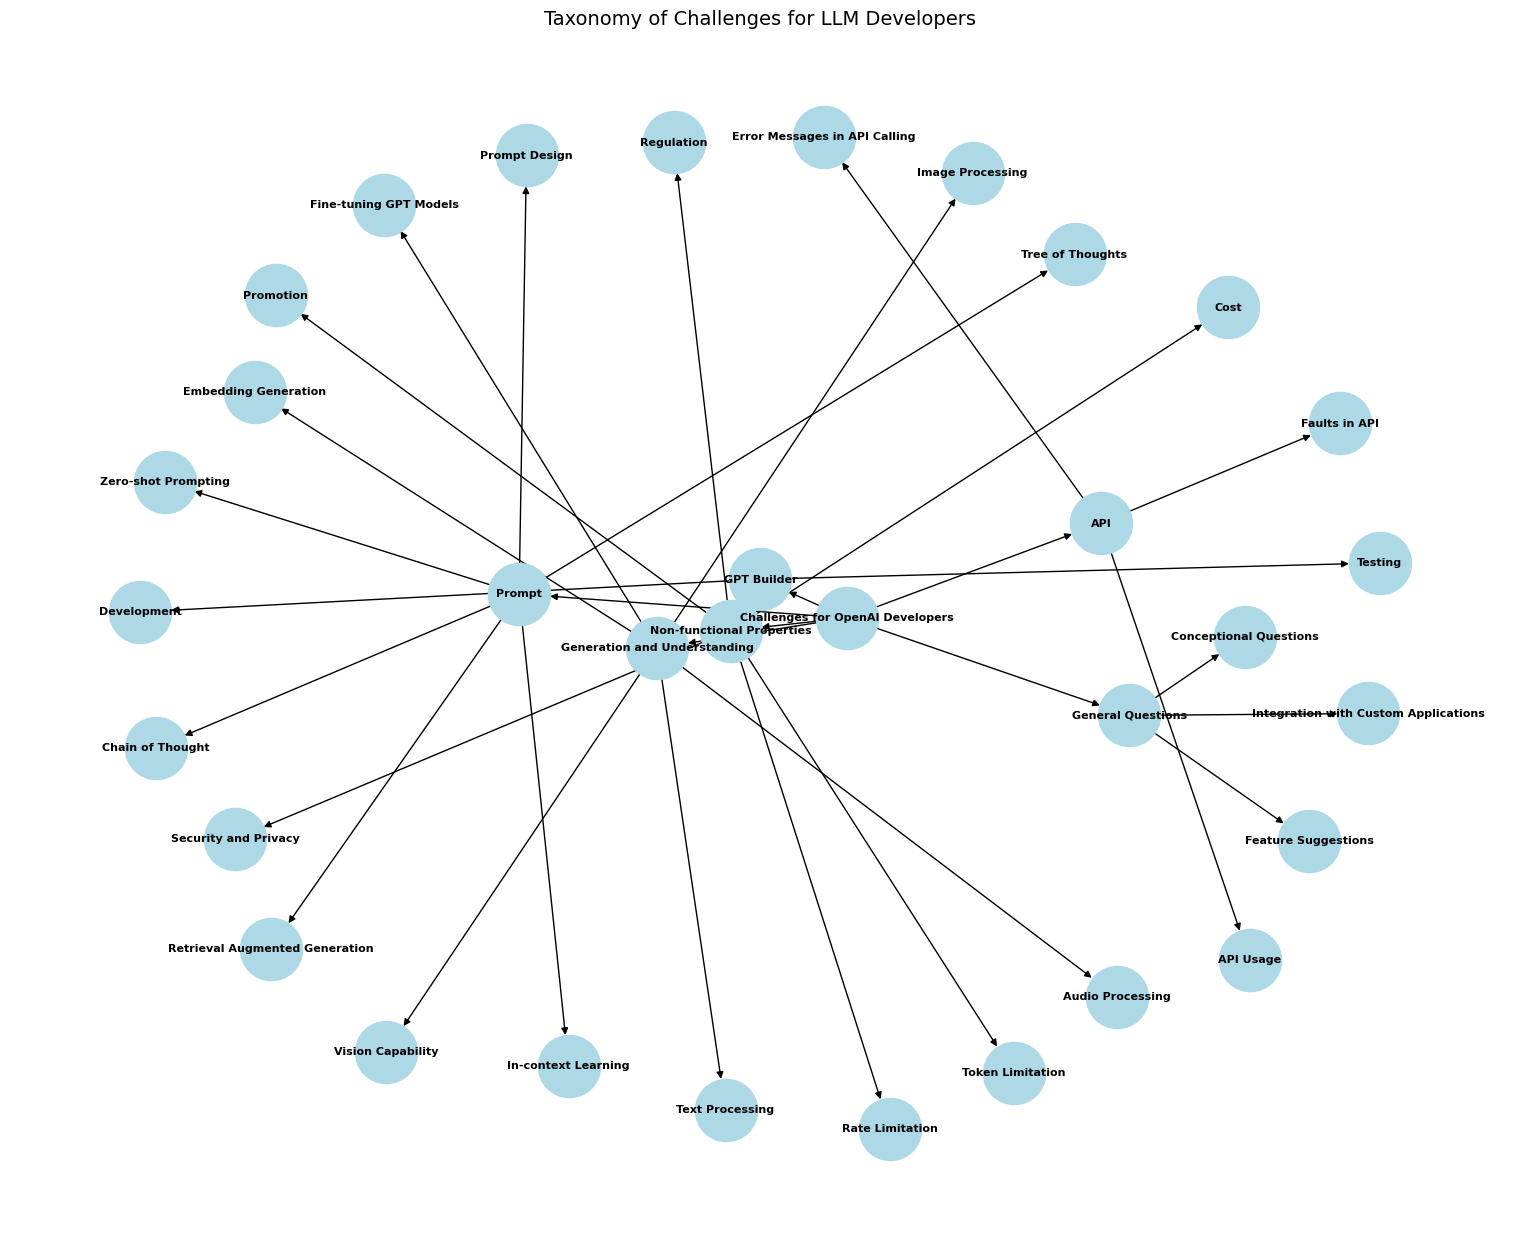

In [2]:
from matplotlib import pyplot as plt
import networkx as nx

# 2. Recreate the challenge taxonomy as a graph
taxonomy = {
    "Challenges for OpenAI Developers": {
        "General Questions": [
            "Integration with Custom Applications",
            "Conceptional Questions",
            "Feature Suggestions"
        ],
        "API": [
            "Faults in API",
            "Error Messages in API Calling",
            "API Usage"
        ],
        "Generation and Understanding": [
            "Text Processing",
            "Fine-tuning GPT Models",
            "Image Processing",
            "Embedding Generation",
            "Audio Processing",
            "Vision Capability"
        ],
        "Non-functional Properties": [
            "Cost",
            "Rate Limitation",
            "Regulation",
            "Promotion",
            "Token Limitation",
            "Security and Privacy"
        ],
        "GPT Builder": [
            "Development",
            "Testing"
        ],
        "Prompt": [
            "Prompt Design",
            "Retrieval Augmented Generation",
            "Chain of Thought",
            "In-context Learning",
            "Zero-shot Prompting",
            "Tree of Thoughts"
        ]
    }
}

# Create a directed graph and add nodes and edges
G = nx.DiGraph()
for outer, middles in taxonomy.items():
    G.add_node(outer)
    for mid, leaves in middles.items():
        G.add_edge(outer, mid)
        for leaf in leaves:
            G.add_edge(mid, leaf)

# Draw the graph
plt.figure(figsize=(15, 12))
pos = nx.spring_layout(G, k=0.45, iterations=60)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=8, font_weight='bold', arrows=True)
plt.title("Taxonomy of Challenges for LLM Developers", fontsize=14)
plt.tight_layout()
plt.show()

# In a markdown file, answer the following:
    #3.1 What are the key design decisions made in their empirical methodology?
L’étude "An Empirical Study on Challenges for LLM Application Developers" repose sur une méthodologie rigoureuse, en quatre étapes principales, pour identifier les défis rencontrés par les développeurs d’applications utilisant des LLMs (Large Language Models), notamment sur les forums OpenAI.

    # Étape 1 : Collecte de données
Les auteurs ont crawlé 29 057 posts du forum développeur OpenAI, en se concentrant sur 4 sous-forums thématiques : API, Prompting, GPT Builders, et ChatGPT.
Les métadonnées récoltées incluent le titre, le corps du message, les tags, le code intégré, les réponses, les auteurs et les temps de réponse.
Objectif : établir une vue d’ensemble des échanges concrets entre développeurs.
    # Étape 2 : Analyse de popularité
Étude temporelle des volumes de posts et d’utilisateurs sur la période 2021–2024 (segmentation par trimestres).
Objectif : identifier les pics d’intérêt liés à la sortie de versions majeures comme GPT-3.5 ou GPT-4.
    # Étape 3 : Analyse de difficulté
    Trois indicateurs ont été mobilisés pour évaluer la complexité des problèmes posés :
      # Nombre de réponses par post (54% des posts ont moins de 3 réponses).
      # Taux de solution acceptée (seulement 8.98%).
      # Temps moyen de première réponse (147 à 278 heures selon le sous-forum).
    Ces métriques confirment que les défis LLM sont plus complexes que ceux rencontrés dans les forums de développement classiques.

    # Étape 4 : Construction de la taxonomie
      # Un échantillon représentatif de 2 364 posts (pour une confiance à 99% ±2,5%) a été analysé manuellement.
      # Une procédure d’open coding a été appliquée par deux annotateurs experts pour induire une taxonomie hiérarchique des défis (multi-niveaux).
      # Les posts "non liés au développement" (bugs d’interface, problèmes de compte...) ont été exclus.
      # Une procédure itérative de lecture, codage, regroupement et arbitrage a permis de raffiner la taxonomie jusqu’à obtention d’un consensus.

    #3.2 How did the authors ensure validity and reliability of their coding procedure?
      # La rigueur du processus de codage qualitatif repose sur deux éléments fondamentaux :
        - la méthode d'annotation et de classification,
        - la mesure de la fiabilité inter-annotateur.
      # Codage collaboratif à deux annotateurs
        - Les deux annotateurs avaient 2 ans d'expérience avec les outils OpenAI et 3 ans d'expérience en développement LLM
      # Étapes :
          # 70 % des 2 364 posts ont été utilisés pour élaborer une taxonomie initiale par open coding.
          # Chaque annotateur lisait au moins deux fois chaque post : titres, descriptions, code, réponses.
          # Ils identifiaient les défis par phrases descriptives simples (ex. : “Problème d’utilisation de l’API : réglage des paramètres”).
          # Un arbitre expert intervenait en cas de désaccord, avec 5 ans d’expérience en développement logiciel et 3 ans en LLM.
      # Fiabilité du codage
          # Les 30 % restants des posts ont servi à une annotation indépendante (sans concertation).
          # Résultat : Cohen’s Kappa = 0.812
              → Cela correspond à un accord quasi parfait, selon les standards classiques en analyse qualitative (Landis & Koch, 1977).
          # En cas de doute :
              # Les posts étaient classés en Pending puis revus par les trois annotateurs ensemble.
          # 5 nouvelles catégories ont été ajoutées si nécessaires.
      # En conclusion, le processus d’annotation garantit une couverture complète (tous les posts liés à OpenAI sont classés), repose sur un cadre rigoureux de validation croisée, et aboutit à une taxonomie exhaustive et robuste comportant 6 grandes familles et 26 sous-catégories.

    #3.3 What kinds of challenges dominate LLM development, according to the data?
      # L’étude met en évidence les principales familles de défis rencontrées par les développeurs d’applications LLM. La taxonomie complète identifie 6 catégories majeures, avec des poids relatifs clairs.
      # Principaux défis :
        # l’intégration des LLM dans des systèmes réels - (A.1 – 17%)
        # la gestion des APIs (paramètres, erreurs, limitations) - (B.1 & B.2 – 16.2%)
        # et la maîtrise des techniques de génération ou d’ajustement du modèle - (C.1 & C.2 – 13.5%).

    #3.4 What implications do these challenges have for the design of LLM platforms or APIs?
        # L’analyse des défis rencontrés par les développeurs LLM permet d’identifier plusieurs implications stratégiques pour les fournisseurs de plateformes (OpenAI, Meta, Google...) et les concepteurs d’APIs.
            # 1. Conception orientée développeurs
              Besoin accru de clarté, de pédagogie et de contrôle :
                # API : les développeurs peinent à comprendre ou exploiter les paramètres (temperature, top_p, frequency_penalty, etc.).
                  # Réponse : fournir une documentation contextuelle, visuelle et interactive, intégrant exemples concrets et simulateur d’impact des paramètres.
                # Error messages : les erreurs retournées sont trop peu explicites.
                  # Réponse : enrichir les messages d’erreur avec des suggestions automatiques (ex. “essayez de baisser la taille du prompt”).
            # 2. Documentation vivante et tutoriels guidés
                # De nombreux défis relèvent d’une compréhension incomplète des bases (tokenisation, appels API, limitations).
                  # Réponse : créer un parcours de montée en compétence progressive : tutoriels guidés (Jupyter, Notebooks interactifs), documentation versionnée, FAQ techniques alimentées automatiquement par les forums (cf. Stack Overflow-like).
            # 3. Support renforcé pour l’intégration dans les applications
                # L’intégration dans des systèmes métiers (ERP, chatbots, apps métier...) est le premier besoin identifié (17%).
                  # Réponse :
                      # proposer des SDK prêts à l’emploi pour différents langages (Python, JS, C#...), avec intégration simplifiée dans des frameworks (FastAPI, Flask, Node...).
                      # Ajouter des templates d’architecture d’intégration (LLM + base vectorielle + front).
            # 4. Sécurité, coûts, et gouvernance des appels API
                # Problèmes récurrents : coûts mal anticipés, dépassement de limites de tokens, inquiétudes sur la confidentialité.
                  # Réponse :
                    # simulateur de coût intégré à l’interface,
                    # affichage dynamique des tokens consommés,
                    # mécanismes de “budget guardrails” (plafonds quotidiens),
                    # et monitoring de sécurité avec alertes personnalisables.
            # 5. Recommandations proactives et support communautaire augmenté par l’IA
               # Lenteur des réponses sur les forums (147h en moyenne), très faible taux de réponse acceptée (8.98%).
                  # Réponse :
                    # mise en place de chatbots communautaires spécialisés,système de recommandation de posts similaires,
                    # intégration d’IA générative pour proposer des réponses ou ébauches de solutions automatiques à partir de la base de posts existante.

    # En conclusion, les résultats de cette étude appellent à une approche centrée développeurs dans la conception de plateformes LLM :
      # Des APIs plus robustes, intelligibles et configurables,
      # Une documentation vivante, multicanale et didactique,
      # et un écosystème de support outillé, avec des outils de monitoring, simulation, et apprentissage guidé